cuda
[[-0.34267565  0.52853546  0.33116893 ... -1.17512437 -1.94816173
  -0.64653999]
 [ 0.78660781  0.89957953  1.02471596 ... -0.9983274  -0.6189742
  -0.78271532]
 [-0.85507174 -1.08828857 -0.95812206 ...  0.6010269  -0.15130802
   0.47858998]
 ...
 [ 0.64388717  0.84789525  0.84236839 ... -0.88075645 -0.4907838
  -0.30234309]
 [-0.76306212 -0.98284332 -1.0175299  ...  1.19245133  0.7687502
   0.7617024 ]
 [-0.93388355 -1.25022951 -1.22804094 ...  1.45945513  0.64553219
   0.79644442]]
[6 0 5 ... 0 5 5]


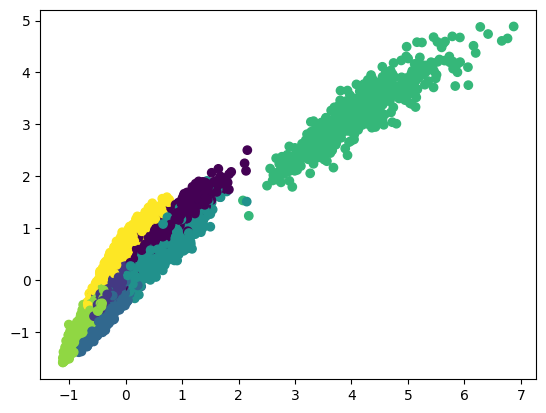

In [1]:
from kan import *
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
import numpy as np
from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

dataset = {}
dry_bean = fetch_ucirepo(id=602) 
  
X = dry_bean.data.features._values
y = dry_bean.data.targets._values[:,0]

class_mapping = {'CALI': 0, 'SIRA': 1, 'SEKER': 2, 'BARBUNYA': 3, 'BOMBAY': 4, 'DERMASON': 5, 'HOROZ': 6}
y = np.vectorize(class_mapping.get)(y)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X, y = shuffle(X, y)

skf = StratifiedKFold(n_splits=5)

print(X)
print(y)
dtype = torch.get_default_dtype()
X_plot = torch.from_numpy(X).type(dtype).to(device)
y_plot = torch.from_numpy(y).type(dtype).to(device)
plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,2].cpu().detach().numpy(), c=y_plot[:].cpu().detach().numpy())
plt.show()

Params: 1680


| train_loss: 4.03e-01 | test_loss: 4.52e-01 | reg: 0.00e+00 | : 100%|█| 800/800 [00:22<00:00, 35.37
| train_loss: 4.00e-01 | test_loss: 4.58e-01 | reg: 0.00e+00 | : 100%|█| 800/800 [00:20<00:00, 39.40
| train_loss: 3.99e-01 | test_loss: 4.73e-01 | reg: 0.00e+00 | : 100%|█| 800/800 [00:20<00:00, 39.40
| train_loss: 4.18e-01 | test_loss: 4.27e-01 | reg: 0.00e+00 | : 100%|█| 800/800 [00:21<00:00, 37.96
| train_loss: 4.01e-01 | test_loss: 4.47e-01 | reg: 0.00e+00 | : 100%|█| 800/800 [00:19<00:00, 41.59


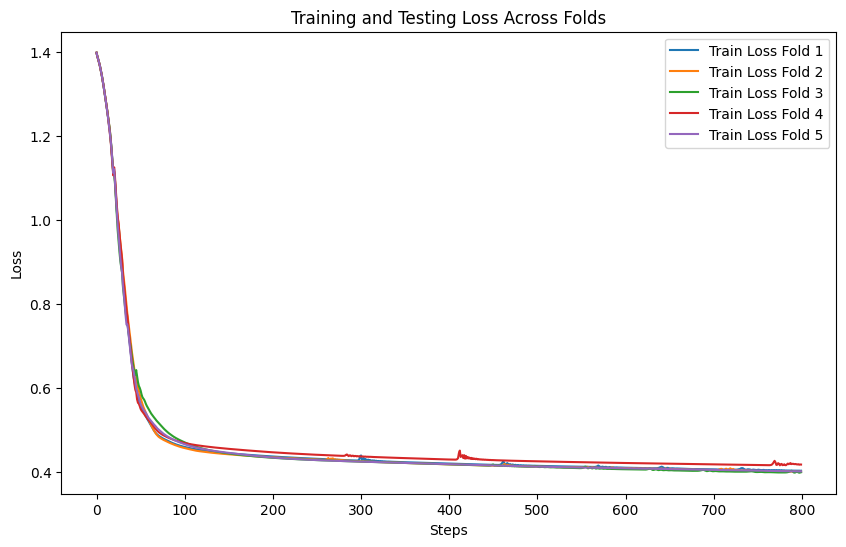

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
import time

dataset = {}
results = []

train_cms = []
test_cms = []

model = None

def compute_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1_score": f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    return metrics
#depth~3 too deep for this dataset
layer=7
KAN_width=[X.shape[1], layer, layer, 7]
KAN_g=3
KAN_k=3

n_params = 0
for i in range(len(KAN_width)-1):
    n_params += KAN_width[i]*KAN_width[i+1]*(KAN_g+KAN_k+2)
print("Params:", n_params)

kan_train_metrics = []
kan_test_metrics = []
time_list=[]

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    
    dataset['train_input'] = torch.from_numpy(X[train_index]).type(torch.FloatTensor).to(device)
    dataset['test_input'] = torch.from_numpy(X[test_index]).type(torch.FloatTensor).to(device)
    dataset['train_label'] = torch.from_numpy(y[train_index]).type(torch.LongTensor).to(device)
    dataset['test_label'] = torch.from_numpy(y[test_index]).type(torch.LongTensor).to(device)

    model = KAN(width=KAN_width, grid=KAN_g, k=KAN_k, device=device, save_act=False, auto_save=False, seed=1)
    
    start_time = time.time()
    results.append(model.fit(dataset, opt="Adam", steps=800, loss_fn=torch.nn.CrossEntropyLoss(), lr=0.01))
    end_time = time.time()
    time_list.append(end_time - start_time)

    train_predictions = torch.argmax(model(dataset['train_input']), dim=1).cpu().numpy()
    test_predictions = torch.argmax(model(dataset['test_input']), dim=1).cpu().numpy()

    train_labels = dataset['train_label'].cpu().numpy()
    test_labels = dataset['test_label'].cpu().numpy()

    #metrics
    kan_train_metrics.append(compute_metrics(train_labels, train_predictions))
    kan_test_metrics.append(compute_metrics(test_labels, test_predictions))
    train_cms.append(confusion_matrix(train_labels, train_predictions))
    test_cms.append(confusion_matrix(test_labels, test_predictions))
    


plt.figure(figsize=(10, 6))

for i, result in enumerate(results):
    plt.plot(result['train_loss'], label=f'Train Loss Fold {i+1}')


plt.legend()
plt.ylabel('Loss')
plt.xlabel('Steps')
plt.title('Training and Testing Loss Across Folds')
plt.yscale('linear')
plt.show()

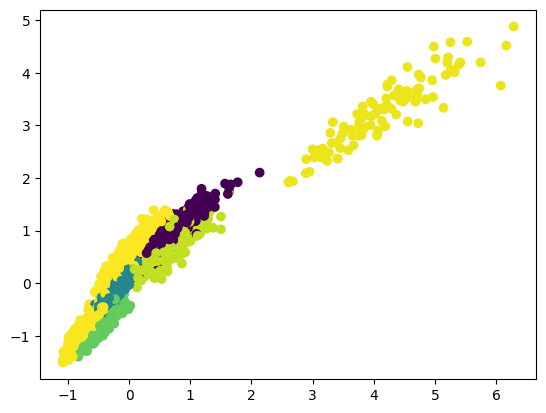

In [3]:
X_plot = dataset['test_input']
y_plot = torch.argmax(model(dataset['test_input']), dim=1)
y_normalized = 1/(1 + np.exp(-y_plot.cpu().detach().numpy()))

plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,2].cpu().detach().numpy(), c=y_normalized)
plt.show()

Train Metrics:
accuracy: 0.9386 ± 0.0020
precision: 0.9510 ± 0.0020
recall: 0.9478 ± 0.0022
f1_score: 0.9493 ± 0.0021

Test Metrics:
accuracy: 0.9292 ± 0.0075
precision: 0.9420 ± 0.0060
recall: 0.9391 ± 0.0070
f1_score: 0.9404 ± 0.0065

Time Metrics: 20.7187 ± 1.1329


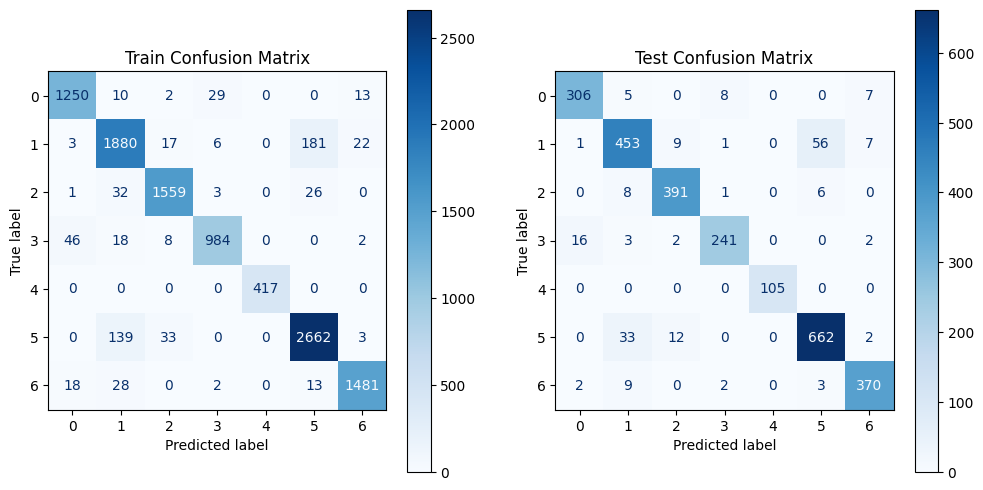

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay

import numpy as np


def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated
def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated

train_metrics_summary = aggregate_metrics(kan_train_metrics)
test_metrics_summary = aggregate_metrics(kan_test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")


with open(f"KAN_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()

MLP

Params: 1799
Train Metrics: {'accuracy': {'mean': np.float64(0.936485186602446), 'std': np.float64(0.0009454134256704341)}, 'precision': {'mean': np.float64(0.948344337676779), 'std': np.float64(0.001206365421933594)}, 'recall': {'mean': np.float64(0.9460344970626109), 'std': np.float64(0.0008454183305522782)}, 'f1_score': {'mean': np.float64(0.9471163023732142), 'std': np.float64(0.0009683064456981357)}}
Test Metrics: {'accuracy': {'mean': np.float64(0.9297624961447684), 'std': np.float64(0.0059278215808784675)}, 'precision': {'mean': np.float64(0.9415417656201986), 'std': np.float64(0.005726474776511238)}, 'recall': {'mean': np.float64(0.9390563652348121), 'std': np.float64(0.0060193489168905556)}, 'f1_score': {'mean': np.float64(0.9401217590052079), 'std': np.float64(0.005848700047490325)}}


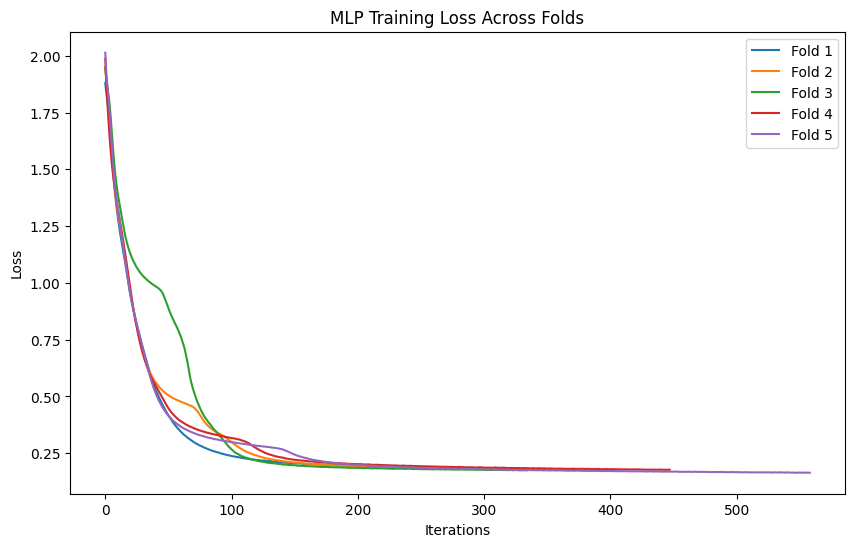

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import time

def compute_metrics(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1_score": f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    return metrics

#depth=3 optimal
leyer=70
hidden_layer_size = (leyer, layer, layer)
params=(X.shape[1], *hidden_layer_size, 7)
n_params = 0
for i in range(len(params)-1):
    n_params += params[i]*params[i+1]+params[i+1]
print("Params:", n_params)

results = []
train_metrics = []
test_metrics = []
time_list=[]

y = y.cpu().detach().numpy() if isinstance(y, torch.Tensor) else y
for train_index, test_index in skf.split(X, y):
    train_input = X[train_index]
    train_label = y[train_index]
    test_input = X[test_index]
    test_label = y[test_index]
    
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_size, activation='logistic', solver='adam', max_iter=800)
    
    start_time = time.time()
    mlp.fit(train_input, train_label)
    end_time = time.time()
    time_list.append(end_time - start_time)
    
    train_predictions = mlp.predict(train_input)
    test_predictions = mlp.predict(test_input)

    results.append(mlp.loss_curve_)
    train_metrics.append(compute_metrics(train_label, train_predictions))
    test_metrics.append(compute_metrics(test_label, test_predictions))

train_metrics_summary = aggregate_metrics(train_metrics)
test_metrics_summary = aggregate_metrics(test_metrics)

print("Train Metrics:", train_metrics_summary)
print("Test Metrics:", test_metrics_summary)

plt.figure(figsize=(10, 6))
for i, loss_curve in enumerate(results):
    plt.plot(loss_curve, label=f'Fold {i+1}')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Across Folds')
plt.legend()
plt.show()

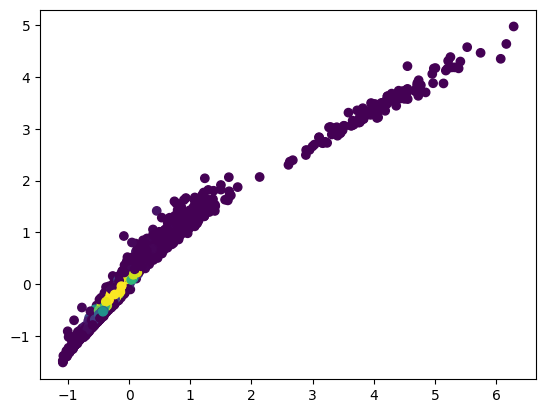

In [6]:
X_plot = dataset['test_input']
y_plot = mlp.predict_proba(dataset['test_input'].cpu().numpy())[:, 1]
plt.scatter(X_plot[:,0].cpu().detach().numpy(), X_plot[:,1].cpu().detach().numpy(), c=y_plot)
plt.show()

Train Metrics:
accuracy: 0.9386 ± 0.0020
precision: 0.9510 ± 0.0020
recall: 0.9478 ± 0.0022
f1_score: 0.9493 ± 0.0021

Test Metrics:
accuracy: 0.9292 ± 0.0075
precision: 0.9420 ± 0.0060
recall: 0.9391 ± 0.0070
f1_score: 0.9404 ± 0.0065

Time Metrics: 22.0184 ± 5.1593


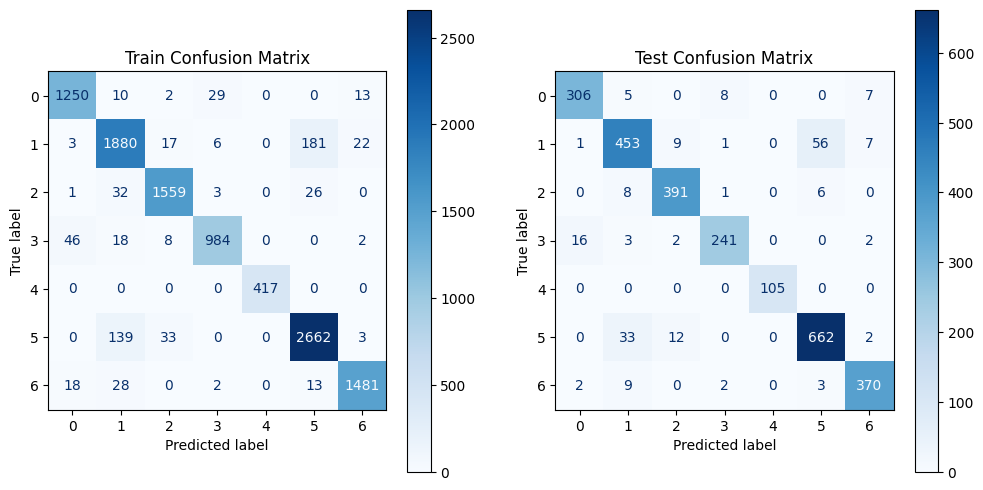

In [7]:
def aggregate_metrics(metrics_list):
    aggregated = {}
    for key in metrics_list[0].keys():
        values = [metrics[key] for metrics in metrics_list]
        aggregated[key] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
    return aggregated
def aggregate_time(time_list):
    aggregated = {
        "mean": np.mean(time_list),
        "std": np.std(time_list)
    }
    return aggregated

train_metrics_summary = aggregate_metrics(kan_train_metrics)
test_metrics_summary = aggregate_metrics(kan_test_metrics)
time_metrics_summary= aggregate_time(time_list)

print("Train Metrics:")
for key, value in train_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print("\nTest Metrics:")
for key, value in test_metrics_summary.items():
    print(f"{key}: {value['mean']:.4f} ± {value['std']:.4f}")
print(f"\nTime Metrics: {time_metrics_summary['mean']:.4f} ± {time_metrics_summary['std']:.4f}")


with open(f"MLP_{n_params}.txt", "w") as file:
    mean=test_metrics_summary["accuracy"]["mean"]
    std=test_metrics_summary["accuracy"]["std"]
    file.write(f"{mean:.4f} {std:.4f}\n")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ConfusionMatrixDisplay(train_cms[0]).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Train Confusion Matrix')
ConfusionMatrixDisplay(test_cms[0]).plot(ax=ax[1], cmap='Blues')
ax[1].set_title('Test Confusion Matrix')

plt.show()